Saving All samples.csv to All samples (1).csv
✅ Dataset loaded successfully!
Shape: (6885, 22)
         Time        Date   temp   Hum  Df_NH3  volt_NH3 MQ_136  Vmq136  \
0  6:05:10 PM  27-05-2023   27.3  30.0    0.78      0.54    0.4    2.06   
1  6:05:11 PM  27-05-2023   27.3  30.0    0.78      0.54   0.38    2.09   
2  6:05:11 PM  27-05-2023   27.3  30.0    0.78      0.54   0.41     2.1   
3  6:05:12 PM  27-05-2023   27.3  30.0    0.78      0.54   0.39    2.11   
4  6:05:12 PM  27-05-2023   27.3  30.0    0.78      0.54    0.4    2.07   

    mq136_Ratio  MQ_135  ...  MQ_2  Vmq2   mq2_Ratio   MQ_4  Vmq4   mq4_Ratio  \
0          3.60    4.34  ...  3.56  0.97        9.85  16.12  2.30        4.42   
1          3.63    4.08  ...  3.42  0.98       10.03  16.12  2.25        4.42   
2          3.57    4.53  ...  3.32  0.98       10.16  16.66  2.28        4.37   
3          3.62    4.12  ...  3.44  1.00       10.00  16.85  2.28        4.35   
4          3.60    3.98  ...  3.59  0.99        9

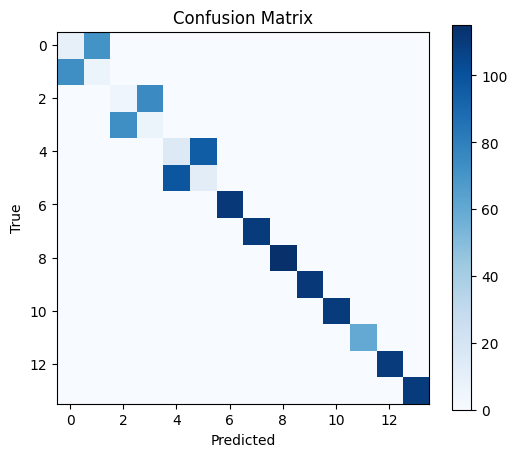

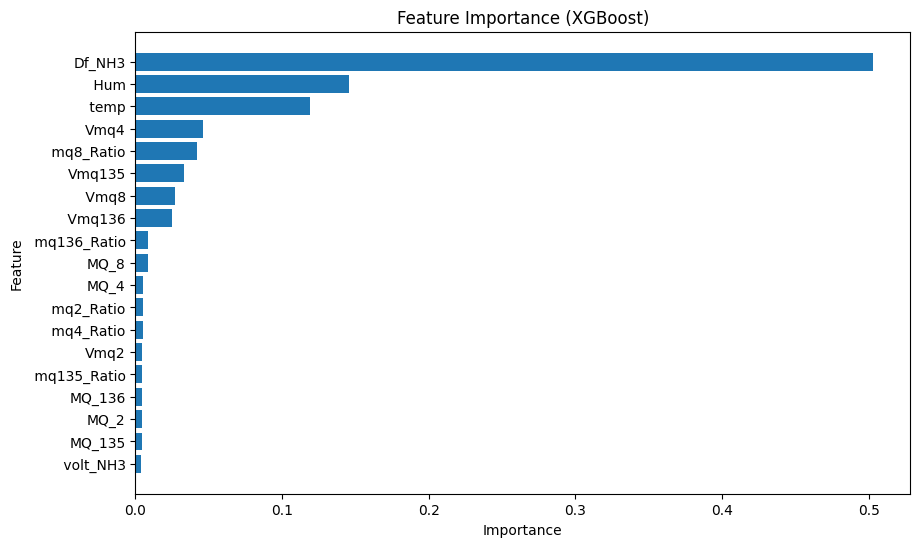

💾 Model saved as clean_smell_xgboost_model.joblib
💾 Target label encoder saved as target_encoder.joblib


In [ ]:


!pip install xgboost scikit-learn pandas matplotlib joblib --quiet

# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
import joblib

# --- Upload Dataset ---
from google.colab import files
uploaded = files.upload()

df = pd.read_csv(next(iter(uploaded)))
print("✅ Dataset loaded successfully!")
print("Shape:", df.shape)
print(df.head())


drop_keywords = ["date", "time", "id", "index", "sample", "no", "num"]
to_drop = [c for c in df.columns if any(k in c.lower() for k in drop_keywords)]

if to_drop:
    print(f"\n🧹 Dropping non-sensor columns: {to_drop}")
    df = df.drop(columns=to_drop)


target_candidates = [c for c in df.columns if c.lower() in ["smell","label","target","class","odor","odour"]]
if target_candidates:
    target_col = target_candidates[0]
else:
    target_col = df.columns[-1]  # fallback to last column

print(f"\n🎯 Target column used: {target_col}")

# --- Split features and labels ---
X = df.drop(columns=[target_col])
y = df[target_col]

# --- Shuffle dataset to remove collection-order bias ---
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# --- Encode non-numeric columns ---
non_numeric_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
print("🔠 Encoding non-numeric columns:", non_numeric_cols)

label_encoders = {}
for col in non_numeric_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

# Encode target if needed
target_encoder = None
if y.dtype == object or y.dtype.name == 'category':
    target_encoder = LabelEncoder()
    y = target_encoder.fit_transform(y.astype(str))
    print("Target classes:", list(target_encoder.classes_))

# --- Handle missing values ---
imputer = SimpleImputer(strategy="mean")
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("\n📊 Train size:", X_train.shape, "Test size:", X_test.shape)

# --- Train XGBoost Model ---
model = XGBClassifier(
    n_estimators=250,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)

print("\n🚀 Training XGBoost model...")
model.fit(X_train, y_train)
print("✅ Training complete!")

# --- Evaluate Model ---
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\n🎯 Accuracy: {acc*100:.2f}%\n")

print("📋 Classification Report:")
print(classification_report(y_test, y_pred))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.show()

# --- Feature Importance ---
plt.figure(figsize=(10,6))
sorted_idx = np.argsort(model.feature_importances_)
plt.barh(np.array(X.columns)[sorted_idx], model.feature_importances_[sorted_idx])
plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# --- Save Model and Encoders ---
joblib.dump(model, "clean_smell_xgboost_model.joblib")
print("💾 Model saved as clean_smell_xgboost_model.joblib")

if target_encoder:
    joblib.dump(target_encoder, "target_encoder.joblib")
    print("💾 Target label encoder saved as target_encoder.joblib")


In [ ]:

import pandas as pd
import numpy as np
import joblib

# --- Load the saved model and encoders ---
model = joblib.load("clean_smell_xgboost_model.joblib")
print("✅ Model loaded successfully!")

# Try loading label encoder if available
try:
    target_encoder = joblib.load("target_encoder.joblib")
    print("✅ Target label encoder loaded!")
except:
    target_encoder = None
    print("⚠️ No target encoder found (predictions will be numeric).")

# --- Step 1️⃣: Define your feature columns (same as training) ---
# You must use the exact column names used during training
# Example: replace these names with your actual sensor column names
# Get the feature names from the trained model
sensor_columns = model.get_booster().feature_names

# --- Step 2️⃣: Enter new sensor readings manually ---
# Example: you can modify these numbers or use input() for runtime entry
# Create a dictionary with the correct feature names and example values
new_data = {
    col: 0 for col in sensor_columns # Initialize with zeros or appropriate default values
}

# 👉 Update the values below with your actual sensor readings for each feature
new_data[" temp"] = 27.5
new_data[" Hum"] = 58.2
new_data["Df_NH3"] = 0.78
new_data[" volt_NH3"] = 1.0 # Example encoded value
new_data["MQ_136"] = 36.0 # Example encoded value
new_data[" Vmq136"] = 1.0 # Example encoded value
new_data[" mq136_Ratio"] = 3.60
new_data["MQ_135"] = 4.34
new_data["Vmq135"] = 0.97
new_data[" mq135_Ratio"] = 9.85
new_data["MQ_2"] = 3.56
new_data["Vmq2"] = 0.97
new_data[" mq2_Ratio"] = 9.85
new_data["MQ_4"] = 16.12
new_data["Vmq4"] = 2.30
new_data[" mq4_Ratio"] = 4.42
new_data["MQ_8"] = 52.31 # Example encoded value
new_data[" Vmq8"] = 1.96 # Example encoded value
new_data[" mq8_Ratio"] = 70.43


# Convert to DataFrame
sample_df = pd.DataFrame([new_data])
print("\n📋 Input Sensor Data:")
display(sample_df)

# --- Step 3️⃣: Predict ---
pred = model.predict(sample_df)[0]

# Decode label if encoder exists
if target_encoder:
    # Ensure the predicted class is within the range of the encoder
    if pred < len(target_encoder.classes_):
        smell_name = target_encoder.inverse_transform([pred])[0]
        print(f"\n👃 Predicted Smell: {smell_name}")
    else:
        print(f"\n👃 Predicted numerical class is out of bounds: {pred}")
else:
    print(f"\n👃 Predicted Smell (numeric class): {pred}")

✅ Model loaded successfully!
✅ Target label encoder loaded!

📋 Input Sensor Data:


,temp,Hum,Df_NH3,volt_NH3,MQ_136,Vmq136,mq136_Ratio,MQ_135,Vmq135,mq135_Ratio,MQ_2,Vmq2,mq2_Ratio,MQ_4,Vmq4,mq4_Ratio,MQ_8,Vmq8,mq8_Ratio
0,27.5,58.2,0.78,1.0,36.0,1.0,3.6,4.34,0.97,9.85,3.56,0.97,9.85,16.12,2.3,4.42,52.31,1.96,70.43



👃 Predicted Smell: Perfume


✅ Dataset loaded: (6885, 22)


,Time,Date,temp,Hum,Df_NH3,volt_NH3,MQ_136,Vmq136,mq136_Ratio,MQ_135,...,MQ_2,Vmq2,mq2_Ratio,MQ_4,Vmq4,mq4_Ratio,MQ_8,Vmq8,mq8_Ratio,Sampe/Class
0,6:05:10 PM,27-05-2023,27.3,30.0,0.78,0.54,0.4,2.06,3.60,4.34,...,3.56,0.97,9.85,16.12,2.30,4.42,52.31,1.96,70.43,Coffee 1
1,6:05:11 PM,27-05-2023,27.3,30.0,0.78,0.54,0.38,2.09,3.63,4.08,...,3.42,0.98,10.03,16.12,2.25,4.42,53.06,1.94,69.00,Coffee 1
2,6:05:11 PM,27-05-2023,27.3,30.0,0.78,0.54,0.41,2.1,3.57,4.53,...,3.32,0.98,10.16,16.66,2.28,4.37,51.87,1.95,71.30,Coffee 1
3,6:05:12 PM,27-05-2023,27.3,30.0,0.78,0.54,0.39,2.11,3.62,4.12,...,3.44,1.00,10.00,16.85,2.28,4.35,52.54,1.97,70.00,Coffee 1
4,6:05:12 PM,27-05-2023,27.3,30.0,0.78,0.54,0.4,2.07,3.60,3.98,...,3.59,0.99,9.82,17.12,2.28,4.32,52.17,1.97,70.72,Coffee 1


🔠 Encoding non-numeric features before imputation: [' Time', ' Date', ' volt_NH3', 'MQ_136', ' Vmq136', 'MQ_8']

🚀 Training XGBoost...
XGBoost Accuracy: 64.78%
              precision    recall  f1-score   support

           0       0.12      0.12      0.12        80
           1       0.08      0.07      0.08        80
           2       0.05      0.05      0.05        80
           3       0.10      0.10      0.10        80
           4       0.12      0.12      0.12       110
           5       0.13      0.13      0.13       110
           6       1.00      1.00      1.00       111
           7       1.00      1.00      1.00       110
           8       1.00      1.00      1.00       115
           9       1.00      1.00      1.00       111
          10       1.00      1.00      1.00       110
          11       1.00      1.00      1.00        60
          12       1.00      1.00      1.00       110
          13       1.00      1.00      1.00       110

    accuracy                

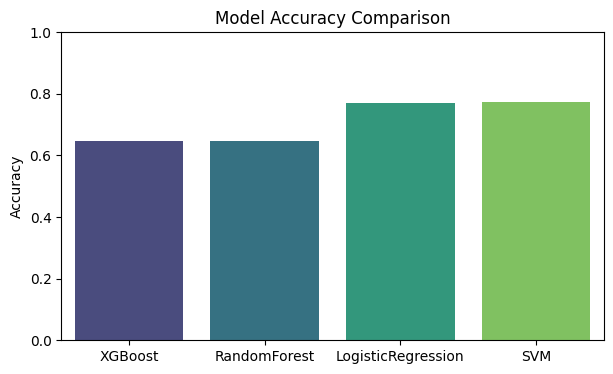

In [ ]:
# ============================================================
# 🌿 SMELL RECOGNITION MULTI-MODEL TRAINING (Colab Version)
# ============================================================

!pip install xgboost scikit-learn pandas numpy joblib matplotlib seaborn --quiet

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

# --- Load dataset ---
df = pd.read_csv("All samples.csv")

# Inspect
print("✅ Dataset loaded:", df.shape)
display(df.head())

# --- Separate features & target ---
target_col = "Sampe/Class"   # <-- Corrected target column name
X = df.drop(columns=[target_col])
y = df[target_col]

# --- Encode target labels ---
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# --- Handle missing data ---
# Automatically detect non-numeric columns for imputation
non_numeric_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric_cols:
    print("🔠 Encoding non-numeric features before imputation:", non_numeric_cols)
    for col in non_numeric_cols:
        # Use LabelEncoder for non-numeric columns in features
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))

X = X.fillna(X.mean())


# --- Scale numeric features ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# --- Define models ---
models = {
    "XGBoost": XGBClassifier(eval_metric='mlogloss', random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(probability=True, kernel='rbf', random_state=42)
}

# --- Train and Evaluate ---
results = {}

for name, model in models.items():
    print(f"\n🚀 Training {name}...")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"{name} Accuracy: {acc*100:.2f}%")
    print(classification_report(y_test, preds))
    print("-" * 60)
    # Save model
    joblib.dump(model, f"{name}_smell_model.joblib")

# --- Save encoders and scalers for future prediction ---
joblib.dump(encoder, "target_encoder.joblib")
joblib.dump(scaler, "scaler.joblib")

# --- Compare visually ---
plt.figure(figsize=(7,4))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette="viridis")
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

In [ ]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import joblib
import pandas as pd
import numpy as np # Import numpy for dtype checking

# Example: load and prepare your data
df = pd.read_csv('All samples.csv')

# --- Automatically detect and remove non-sensor columns ---
# Columns that are likely metadata or cause leakage
drop_keywords = ["date", "time", "id", "index", "sample", "no", "num"]
to_drop = [c for c in df.columns if any(k in c.lower() for k in drop_keywords)]

if to_drop:
    print(f"\n🧹 Dropping non-sensor columns: {to_drop}")
    df = df.drop(columns=to_drop)

X = df.drop(columns=['Sampe/Class'])     # features # Corrected target column name
y = df['Sampe/Class']                    # target variable # Corrected target column name

# --- Encode non-numeric columns in features (X) ---
non_numeric_cols_X = X.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric_cols_X:
    print("🔠 Encoding non-numeric feature columns:", non_numeric_cols_X)
    label_encoders_X = {}
    for col in non_numeric_cols_X:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        label_encoders_X[col] = le # Optionally save these encoders if needed for prediction

# encode target
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

# scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)

# train model
model = XGBClassifier(eval_metric='mlogloss')
model.fit(X_train, y_train)

# ✅ save model + encoders
joblib.dump(model, 'clean_smell_xgboost_model.joblib')
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(target_encoder, 'target_encoder.joblib')


🧹 Dropping non-sensor columns: [' Time', ' Date']
🔠 Encoding non-numeric feature columns: [' volt_NH3', 'MQ_136', ' Vmq136', 'MQ_8']


['target_encoder.joblib']

In [ ]:
from google.colab import files
files.download('clean_smell_xgboost_model.joblib')
files.download('scaler.joblib')
files.download('target_encoder.joblib')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

files.download('RandomForest_smell_model.joblib')
files.download('SVM_smell_model.joblib')
files.download('LogisticRegression_smell_model.joblib')

# If you have these, download them too
files.download('scaler.joblib')
files.download('target_encoder.joblib')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
print("Upload smell_gradio_app.py and all .joblib files")
uploaded = files.upload()


Upload smell_gradio_app.py and all .joblib files


Saving clean_smell_xgboost_model.joblib to clean_smell_xgboost_model.joblib
Saving LogisticRegression_smell_model.joblib to LogisticRegression_smell_model.joblib
Saving RandomForest_smell_model.joblib to RandomForest_smell_model.joblib
Saving scaler.joblib to scaler.joblib
Saving smell_gradio_app.py to smell_gradio_app (1).py
Saving SVM_smell_model.joblib to SVM_smell_model.joblib
Saving target_encoder.joblib to target_encoder.joblib


In [ ]:
!pip install gradio joblib pandas scikit-learn xgboost


In [ ]:
!python smell_gradio_app.py


/usr/local/lib/python3.12/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(
* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://cd77fcf31b1b932383.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
